### ResNet-34 vs ResNet-50 on CIFAR-10


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import Compose, Normalize, ToTensor

In [2]:
SEED = 12
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
NUM_CLASSES = 10
VAL_RATIO = 0.1
DATA_DIR = Path("data") # 실험 공통조건 

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## 1. CIFAR-10 데이터셋

CIFAR-10 이미지는 `[C, H, W] = [3, 32, 32]`이며 클래스는 10개이다. 공식 train 50,000장을 고정 seed로 train 45,000장과 validation 5,000장으로 분리한다. 공식 test 10,000장은 학습 중 모델 비교에 사용하지 않는다.

In [3]:
cifar10_transform = Compose([
    ToTensor(),
    Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
]) # CIFAR-10 데이터셋의 표준 정규화 

full_training_data = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=cifar10_transform,
)

test_data = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=cifar10_transform,
)

val_size = int(len(full_training_data) * VAL_RATIO)
train_size = len(full_training_data) - val_size
training_data, validation_data = random_split(
    full_training_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)


def make_train_dataloader():
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        training_data,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


val_dataloader = DataLoader(
    validation_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

sample_images, sample_labels = next(iter(val_dataloader))
print(f"Image batch: {sample_images.shape}")
print(f"Label batch: {sample_labels.shape}")
print(f"Train samples: {len(training_data)}")
print(f"Validation samples: {len(validation_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Classes: {full_training_data.classes}")

Files already downloaded and verified
Files already downloaded and verified
Image batch: torch.Size([64, 3, 32, 32])
Label batch: torch.Size([64])
Train samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### ResNet-34/50 구현 

ResNet-34는 BasicBlock, ResNet-50은 BottleneckBlock을 사용한다. 두 block 모두 main branch에서 `F(x)`를 학습하고 shortcut의 `x`를 더해 `F(x) + x`를 만든다.

stage가 바뀌면서 stride 또는 channel이 달라질 때는 `1×1 convolution` projection shortcut으로 두 branch의 shape을 맞춘다.

In [4]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False,
    )


def conv1x1(in_channels, out_channels, stride=1):
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        bias=False,
    )

In [5]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                conv1x1(
                    in_channels,
                    out_channels * self.expansion,
                    stride,
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)
        return out


class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 1x1: channel 축소
        self.conv1 = conv1x1(in_channels, out_channels)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3: 특징 추출 및 stage 전환 시 공간 크기 축소
        self.conv2 = conv3x3(out_channels, out_channels, stride)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1: channel을 expansion=4만큼 확장
        final_channels = out_channels * self.expansion
        self.conv3 = conv1x1(out_channels, final_channels)
        self.bn3 = nn.BatchNorm2d(final_channels)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_channels != final_channels:
            self.downsample = nn.Sequential(
                conv1x1(in_channels, final_channels, stride),
                nn.BatchNorm2d(final_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)
        return out

In [6]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super().__init__()
        self.in_channels = 64

        # CIFAR-10의 32x32 입력에 맞춰 초기 downsampling을 제거한다.
        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.Identity()

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = [block(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


RESNET_CONFIGS = {
    "resnet34": {
        "block": BasicBlock,
        "layers": [3, 4, 6, 3],
    },
    "resnet50": {
        "block": BottleneckBlock,
        "layers": [3, 4, 6, 3],
    },
}


def build_resnet(model_name, num_classes=NUM_CLASSES):
    config = RESNET_CONFIGS[model_name]
    return ResNet(
        block=config["block"],
        layers=config["layers"],
        num_classes=num_classes,
    )

### Shape 확인

CIFAR-10용 stem은 `3×3 convolution, stride=1`을 사용하고 초기 MaxPool을 제거한다.

```text
입력  32×32
layer1     32×32
layer2     16×16
layer3      8×8
layer4      4×4
avgpool     1×1
```

`layer2[0]`에서 ResNet-34는 양쪽 branch가 `[N, 128, 16, 16]`, expansion=4인 ResNet-50은 `[N, 512, 16, 16]`가 되어야 더할 수 있다.

In [7]:
EXPECTED_STAGE_SHAPES = {
    "resnet34": [
        (2, 64, 32, 32),
        (2, 128, 16, 16),
        (2, 256, 8, 8),
        (2, 512, 4, 4),
    ],
    "resnet50": [
        (2, 256, 32, 32),
        (2, 512, 16, 16),
        (2, 1024, 8, 8),
        (2, 2048, 4, 4),
    ],
}


def check_resnet_structure(model_name):
    model = build_resnet(model_name).to(device)
    stage_shapes = [{} for _ in range(4)]
    hooks = []

    for stage_index, layer in enumerate(
        [model.layer1, model.layer2, model.layer3, model.layer4]
    ):
        first_block = layer[0]
        main_bn = first_block.bn3 if hasattr(first_block, "bn3") else first_block.bn2

        def save_input(module, inputs, index=stage_index):
            stage_shapes[index]["input"] = tuple(inputs[0].shape)

        def save_main(module, inputs, output, index=stage_index):
            stage_shapes[index]["main"] = tuple(output.shape)

        hooks.append(first_block.register_forward_pre_hook(save_input))
        hooks.append(main_bn.register_forward_hook(save_main))

        if first_block.downsample is not None:
            def save_shortcut(module, inputs, output, index=stage_index):
                stage_shapes[index]["shortcut"] = tuple(output.shape)

            hooks.append(first_block.downsample.register_forward_hook(save_shortcut))

    with torch.no_grad():
        output = model(sample_images[:2].to(device))

    for hook in hooks:
        hook.remove()

    for stage_index, shapes in enumerate(stage_shapes):
        shortcut_shape = shapes.get("shortcut", shapes["input"])
        expected_shape = EXPECTED_STAGE_SHAPES[model_name][stage_index]
        print(
            f"{model_name} layer{stage_index + 1}: "
            f"main={shapes['main']}, shortcut={shortcut_shape}"
        )
        assert shapes["main"] == shortcut_shape == expected_shape

    assert [len(model.layer1), len(model.layer2), len(model.layer3), len(model.layer4)] == [3, 4, 6, 3]
    expected_expansion = 1 if model_name == "resnet34" else 4
    assert model.layer1[0].expansion == expected_expansion
    assert output.shape == (2, NUM_CLASSES)
    print(f"{model_name} output: {tuple(output.shape)}")


check_resnet_structure("resnet34")
check_resnet_structure("resnet50")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


resnet34 layer1: main=(2, 64, 32, 32), shortcut=(2, 64, 32, 32)
resnet34 layer2: main=(2, 128, 16, 16), shortcut=(2, 128, 16, 16)
resnet34 layer3: main=(2, 256, 8, 8), shortcut=(2, 256, 8, 8)
resnet34 layer4: main=(2, 512, 4, 4), shortcut=(2, 512, 4, 4)
resnet34 output: (2, 10)
resnet50 layer1: main=(2, 256, 32, 32), shortcut=(2, 256, 32, 32)
resnet50 layer2: main=(2, 512, 16, 16), shortcut=(2, 512, 16, 16)
resnet50 layer3: main=(2, 1024, 8, 8), shortcut=(2, 1024, 8, 8)
resnet50 layer4: main=(2, 2048, 4, 4), shortcut=(2, 2048, 4, 4)
resnet50 output: (2, 10)


In [8]:
for model_name in ("resnet34", "resnet50"):
    preview_model = build_resnet(model_name)
    parameter_count = sum(p.numel() for p in preview_model.parameters())
    print(f"{model_name} parameters: {parameter_count:,}")

del preview_model

resnet34 parameters: 21,282,122
resnet50 parameters: 23,520,842


In [9]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = X.size(0)
        total_loss += loss.item() * batch_size
        correct += (pred.argmax(1) == y).sum().item()
        total += batch_size

    return total_loss / total, correct / total


def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)

            batch_size = X.size(0)
            total_loss += loss.item() * batch_size
            correct += (pred.argmax(1) == y).sum().item()
            total += batch_size

    return total_loss / total, correct / total

In [10]:
def fit_model(model, model_name):
    train_dataloader = make_train_dataloader()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_dataloader, loss_fn, optimizer
        )
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{model_name} | Epoch [{epoch + 1}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history

## 5. ResNet-34 학습

BasicBlock을 사용하는 ResNet-34를 pretrained weight 없이 처음부터 학습한다.

In [11]:
torch.manual_seed(SEED)
resnet34_model = build_resnet("resnet34").to(device)
resnet34_history = fit_model(resnet34_model, "ResNet-34")

ResNet-34 | Epoch [1/10] Train Loss: 1.8289 | Train Acc: 0.3174 | Val Loss: 1.9099 | Val Acc: 0.3234
ResNet-34 | Epoch [2/10] Train Loss: 1.4790 | Train Acc: 0.4569 | Val Loss: 1.4573 | Val Acc: 0.4670
ResNet-34 | Epoch [3/10] Train Loss: 1.2947 | Train Acc: 0.5266 | Val Loss: 1.4074 | Val Acc: 0.5094
ResNet-34 | Epoch [4/10] Train Loss: 1.1407 | Train Acc: 0.5906 | Val Loss: 1.4316 | Val Acc: 0.5130
ResNet-34 | Epoch [5/10] Train Loss: 1.0089 | Train Acc: 0.6378 | Val Loss: 1.6025 | Val Acc: 0.4866
ResNet-34 | Epoch [6/10] Train Loss: 0.8939 | Train Acc: 0.6848 | Val Loss: 1.0860 | Val Acc: 0.6220
ResNet-34 | Epoch [7/10] Train Loss: 0.7817 | Train Acc: 0.7260 | Val Loss: 1.2026 | Val Acc: 0.5948
ResNet-34 | Epoch [8/10] Train Loss: 0.6733 | Train Acc: 0.7658 | Val Loss: 1.2374 | Val Acc: 0.5994
ResNet-34 | Epoch [9/10] Train Loss: 0.5658 | Train Acc: 0.8066 | Val Loss: 2.0849 | Val Acc: 0.4968
ResNet-34 | Epoch [10/10] Train Loss: 0.4561 | Train Acc: 0.8457 | Val Loss: 1.3760 | Val A

Best Epoch : 5(80.44) 

## 6. ResNet-50 학습

Bottleneck connection을 사용하는 기본 ResNet-50을 pretrained weight 없이 처음부터 학습한다.

In [12]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

torch.manual_seed(SEED)
resnet50_model = build_resnet("resnet50").to(device)
resnet50_history = fit_model(resnet50_model, "ResNet-50")

ResNet-50 | Epoch [1/10] Train Loss: 2.0729 | Train Acc: 0.2218 | Val Loss: 1.9002 | Val Acc: 0.2886


KeyboardInterrupt: 

## 7. 결과 비교


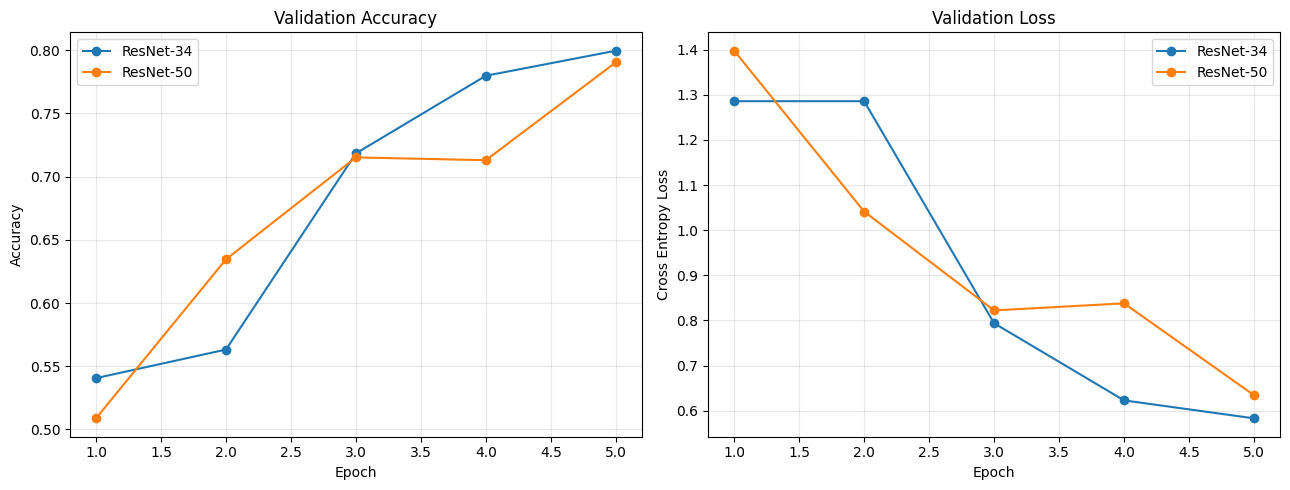

ResNet-34 best validation accuracy: 0.7996
ResNet-50 best validation accuracy: 0.7904


In [ ]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    epochs_range,
    resnet34_history["val_acc"],
    marker="o",
    label="ResNet-34",
)
axes[0].plot(
    epochs_range,
    resnet50_history["val_acc"],
    marker="o",
    label="ResNet-50",
)
axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    epochs_range,
    resnet34_history["val_loss"],
    marker="o",
    label="ResNet-34",
)
axes[1].plot(
    epochs_range,
    resnet50_history["val_loss"],
    marker="o",
    label="ResNet-50",
)
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross Entropy Loss")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    f"ResNet-34 best validation accuracy: "
    f"{max(resnet34_history['val_acc']):.4f}"
)
print(
    f"ResNet-50 best validation accuracy: "
    f"{max(resnet50_history['val_acc']):.4f}"
)

epoch=5 조건은 두 모델의 학습이 충분히 수렴하기에는 부족한 것으로 보인다.   
(baseline 비교 추가해야함)  
두 모델 모두 best epoch가 마지막 epoch인 5에서 나타났으므로, 추가 학습을 진행할 경우 성능이 더 향상될 가능성이 있다. 또한 ResNet-34가 ResNet-50보다 더 빠르게 학습되는 경향을 보였는데, 이는 ResNet-50의 BottleneckBlock이 block당 더 많은 convolution과 BatchNorm 계층을 포함하고, expansion=4로 인해 projection shortcut도 함께 학습해야 하기 때문으로 해석할 수 있다. 따라서 짧은 학습 조건에서는 ResNet-50의 더 깊고 복잡한 구조가 충분히 안정화되지 못해 ResNet-34보다 느린 수렴을 보였을 가능성이 있다.


### 추가 실험 - epoch 10, resnet-50 full pre-activation 추가

ResNet에게 epoch = 5가 수렴하기에는 아직 부족한 면이 있기 때문에 학습을 늘리고, 이전 개인 경험상 성능이 좋았던 BN/ReLU가 앞에 붙는 ResNet-50을 추가하여 실험을 진행하였다.  

In [ ]:
class PreActBottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # Full pre-activation: 각 convolution 전에 BN과 ReLU를 적용한다.
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = conv1x1(in_channels, out_channels)

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = conv3x3(out_channels, out_channels, stride)

        self.bn3 = nn.BatchNorm2d(out_channels)
        self.conv3 = conv1x1(
            out_channels,
            out_channels * self.expansion,
        )

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = conv1x1(
                in_channels,
                out_channels * self.expansion,
                stride,
            )

    def forward(self, x):
        preact = self.relu(self.bn1(x))
        identity = (
            self.downsample(preact)
            if self.downsample is not None
            else x
        )

        out = self.conv1(preact)
        out = self.conv2(self.relu(self.bn2(out)))
        out = self.conv3(self.relu(self.bn3(out)))

        # Full pre-activation에서는 residual 덧셈 뒤에 ReLU를 적용하지 않는다.
        return out + identity


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_channels = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced_channels),
            nn.ReLU(inplace=True),
            nn.Linear(reduced_channels, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.shape
        weights = self.pool(x).view(batch_size, channels)
        weights = self.fc(weights).view(batch_size, channels, 1, 1)
        return x * weights


class SEBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels, reduction=16)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                conv1x1(in_channels, out_channels, stride),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        return self.relu(out)

In [ ]:
class FollowupResNet(nn.Module):
    def __init__(self, block, layers, num_classes=NUM_CLASSES):
        super().__init__()
        self.in_channels = 64
        self.is_preact = block is PreActBottleneckBlock

        # 현재 CIFAR-10 실험과 동일한 32x32용 stem을 사용한다.
        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.Identity()

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        final_channels = 512 * block.expansion
        self.final_bn = (
            nn.BatchNorm2d(final_channels)
            if self.is_preact
            else nn.Identity()
        )
        self.final_relu = nn.ReLU(inplace=True) if self.is_preact else nn.Identity()
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(final_channels, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = [block(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.final_relu(self.final_bn(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


FOLLOWUP_CONFIGS = {
    "resnet34": {"block": BasicBlock, "layers": [3, 4, 6, 3]},
    "resnet50": {"block": BottleneckBlock, "layers": [3, 4, 6, 3]},
    "resnet50_preact": {
        "block": PreActBottleneckBlock,
        "layers": [3, 4, 6, 3],
    },
    "se_resnet34": {
        "block": SEBasicBlock,
        "layers": [3, 4, 6, 3],
    },
}


def build_followup_resnet(model_name, num_classes=NUM_CLASSES):
    config = FOLLOWUP_CONFIGS[model_name]
    return FollowupResNet(
        block=config["block"],
        layers=config["layers"],
        num_classes=num_classes,
    )

In [ ]:
def check_preact_shapes():
    model = build_followup_resnet("resnet50_preact").to(device)
    model.eval()
    expected_shapes = [
        (2, 256, 32, 32),
        (2, 512, 16, 16),
        (2, 1024, 8, 8),
        (2, 2048, 4, 4),
    ]

    with torch.no_grad():
        x = torch.randn(2, 3, 32, 32, device=device)
        x = model.maxpool(model.relu(model.bn1(model.conv1(x))))

        for stage_index, (layer, expected_shape) in enumerate(
            zip(
                [model.layer1, model.layer2, model.layer3, model.layer4],
                expected_shapes,
            ),
            start=1,
        ):
            first_block = layer[0]
            preact = first_block.relu(first_block.bn1(x))
            shortcut = (
                first_block.downsample(preact)
                if first_block.downsample is not None
                else x
            )
            main = first_block.conv1(preact)
            main = first_block.conv2(
                first_block.relu(first_block.bn2(main))
            )
            main = first_block.conv3(
                first_block.relu(first_block.bn3(main))
            )

            assert tuple(main.shape) == expected_shape
            assert tuple(shortcut.shape) == expected_shape
            print(
                f"PreAct layer{stage_index}: "
                f"main={tuple(main.shape)}, shortcut={tuple(shortcut.shape)}"
            )
            x = layer(x)

        output = model.fc(
            torch.flatten(
                model.avgpool(model.final_relu(model.final_bn(x))),
                1,
            )
        )
        assert output.shape == (2, NUM_CLASSES)
        print(f"PreAct output: {tuple(output.shape)}")


check_preact_shapes()


def check_se_resnet34_shapes():
    model = build_followup_resnet("se_resnet34").to(device)
    baseline = build_followup_resnet("resnet34").to(device)
    model.eval()
    expected_shapes = [
        (2, 64, 32, 32),
        (2, 128, 16, 16),
        (2, 256, 8, 8),
        (2, 512, 4, 4),
    ]

    with torch.no_grad():
        x = torch.randn(2, 3, 32, 32, device=device)
        x = model.maxpool(model.relu(model.bn1(model.conv1(x))))

        for stage_index, (layer, expected_shape) in enumerate(
            zip(
                [model.layer1, model.layer2, model.layer3, model.layer4],
                expected_shapes,
            ),
            start=1,
        ):
            first_block = layer[0]
            identity = (
                first_block.downsample(x)
                if first_block.downsample is not None
                else x
            )
            main = first_block.relu(first_block.bn1(first_block.conv1(x)))
            main = first_block.bn2(first_block.conv2(main))
            se_main = first_block.se(main)

            assert main.shape == se_main.shape
            assert tuple(se_main.shape) == expected_shape
            assert tuple(identity.shape) == expected_shape
            print(
                f"SE layer{stage_index}: main={tuple(se_main.shape)}, "
                f"shortcut={tuple(identity.shape)}"
            )
            x = layer(x)

        output = model(torch.randn(2, 3, 32, 32, device=device))
        assert output.shape == (2, NUM_CLASSES)

    baseline_params = sum(p.numel() for p in baseline.parameters())
    se_params = sum(p.numel() for p in model.parameters())
    assert se_params > baseline_params
    print(f"SE-ResNet-34 output: {tuple(output.shape)}")
    print(f"ResNet-34 parameters: {baseline_params:,}")
    print(f"SE-ResNet-34 parameters: {se_params:,}")


check_se_resnet34_shapes()

PreAct layer1: main=(2, 256, 32, 32), shortcut=(2, 256, 32, 32)
PreAct layer2: main=(2, 512, 16, 16), shortcut=(2, 512, 16, 16)
PreAct layer3: main=(2, 1024, 8, 8), shortcut=(2, 1024, 8, 8)
PreAct layer4: main=(2, 2048, 4, 4), shortcut=(2, 2048, 4, 4)
PreAct output: (2, 10)
SE layer1: main=(2, 64, 32, 32), shortcut=(2, 64, 32, 32)
SE layer2: main=(2, 128, 16, 16), shortcut=(2, 128, 16, 16)
SE layer3: main=(2, 256, 8, 8), shortcut=(2, 256, 8, 8)
SE layer4: main=(2, 512, 4, 4), shortcut=(2, 512, 4, 4)
SE-ResNet-34 output: (2, 10)
ResNet-34 parameters: 21,282,122
SE-ResNet-34 parameters: 21,443,318


In [ ]:
FOLLOWUP_EPOCHS = 10


def fit_followup_model(model, model_name):
    train_dataloader = make_train_dataloader()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(FOLLOWUP_EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_dataloader, loss_fn, optimizer
        )
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{model_name} | Epoch [{epoch + 1}/{FOLLOWUP_EPOCHS}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    assert all(len(values) == FOLLOWUP_EPOCHS for values in history.values())
    return history


def train_followup_experiment(config_name, display_name):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = build_followup_resnet(config_name).to(device)
    history = fit_followup_model(model, display_name)
    return model, history


resnet34_model_10ep, resnet34_history_10ep = train_followup_experiment(
    "resnet34", "ResNet-34 (10 epoch)"
)
resnet50_model_10ep, resnet50_history_10ep = train_followup_experiment(
    "resnet50", "ResNet-50 (10 epoch)"
)
resnet50_preact_model_10ep, resnet50_preact_history_10ep = (
    train_followup_experiment(
        "resnet50_preact", "ResNet-50-PreAct (10 epoch)"
    )
)
se_resnet34_model_10ep, se_resnet34_history_10ep = (
    train_followup_experiment(
        "se_resnet34", "SE-ResNet-34 (10 epoch)"
    )
)

ResNet-34 (10 epoch) | Epoch [1/10] Train Loss: 1.5861 | Train Acc: 0.4122 | Val Loss: 1.3927 | Val Acc: 0.5338
ResNet-34 (10 epoch) | Epoch [2/10] Train Loss: 1.0622 | Train Acc: 0.6205 | Val Loss: 0.9945 | Val Acc: 0.6622
ResNet-34 (10 epoch) | Epoch [3/10] Train Loss: 0.7954 | Train Acc: 0.7205 | Val Loss: 0.9075 | Val Acc: 0.7238
ResNet-34 (10 epoch) | Epoch [4/10] Train Loss: 0.6188 | Train Acc: 0.7849 | Val Loss: 0.7902 | Val Acc: 0.7204
ResNet-34 (10 epoch) | Epoch [5/10] Train Loss: 0.4938 | Train Acc: 0.8285 | Val Loss: 0.5871 | Val Acc: 0.8054
ResNet-34 (10 epoch) | Epoch [6/10] Train Loss: 0.3910 | Train Acc: 0.8627 | Val Loss: 0.5225 | Val Acc: 0.8220
ResNet-34 (10 epoch) | Epoch [7/10] Train Loss: 0.3054 | Train Acc: 0.8947 | Val Loss: 0.6011 | Val Acc: 0.8122
ResNet-34 (10 epoch) | Epoch [8/10] Train Loss: 0.2285 | Train Acc: 0.9196 | Val Loss: 0.5656 | Val Acc: 0.8272
ResNet-34 (10 epoch) | Epoch [9/10] Train Loss: 0.1642 | Train Acc: 0.9410 | Val Loss: 0.6028 | Val Acc:

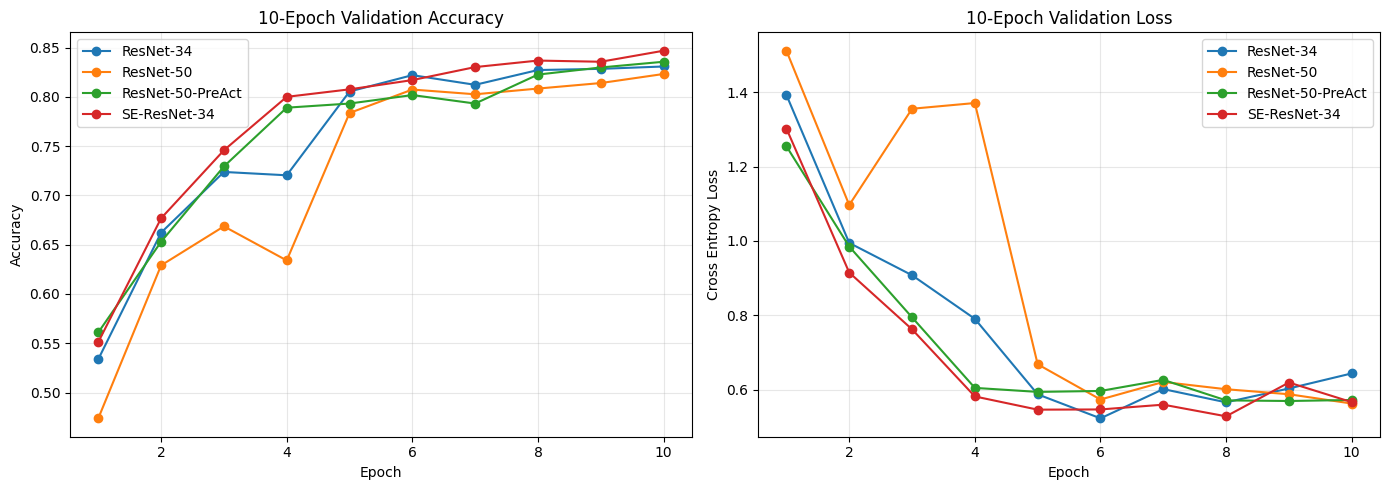

ResNet-34 best validation accuracy: 0.8308 (epoch 10)
ResNet-50 best validation accuracy: 0.8232 (epoch 10)
ResNet-50-PreAct best validation accuracy: 0.8356 (epoch 10)
SE-ResNet-34 best validation accuracy: 0.8468 (epoch 10)


In [ ]:
followup_histories = {
    "ResNet-34": resnet34_history_10ep,
    "ResNet-50": resnet50_history_10ep,
    "ResNet-50-PreAct": resnet50_preact_history_10ep,
    "SE-ResNet-34": se_resnet34_history_10ep,
}
followup_epochs = range(1, FOLLOWUP_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, history in followup_histories.items():
    assert len(history["val_acc"]) == FOLLOWUP_EPOCHS
    assert len(history["val_loss"]) == FOLLOWUP_EPOCHS
    axes[0].plot(
        followup_epochs,
        history["val_acc"],
        marker="o",
        label=model_name,
    )
    axes[1].plot(
        followup_epochs,
        history["val_loss"],
        marker="o",
        label=model_name,
    )

axes[0].set_title("10-Epoch Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("10-Epoch Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross Entropy Loss")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

for model_name, history in followup_histories.items():
    best_epoch = int(np.argmax(history["val_acc"])) + 1
    best_accuracy = max(history["val_acc"])
    print(
        f"{model_name} best validation accuracy: "
        f"{best_accuracy:.4f} (epoch {best_epoch})"
    )

## SE-ResNet-34 해석 기준

- SEBlock은 feature map의 공간 위치를 직접 선택하는 attention이 아니라, global average pooling으로 각 channel의 전체 정보를 요약한 뒤 channel별 중요도를 학습한다.
- 계산된 가중치 shape은 `[B, C, 1, 1]`이며 broadcasting을 통해 원래 `[B, C, H, W]` feature map의 channel 전체에 곱해진다.
- SEBasicBlock에서는 두 번째 `conv → BN` 뒤, shortcut과 더하기 전에 SEBlock을 적용한다. 따라서 main branch와 shortcut branch의 shape은 기존 BasicBlock과 동일해야 한다.
- ResNet-34와 SE-ResNet-34는 stage 구성과 학습 조건이 같으므로, 두 모델의 차이는 channel attention 추가 효과를 중심으로 비교한다.
- SEBlock은 channel별 관계를 학습하는 fully connected layer를 추가하므로 기본 ResNet-34보다 파라미터 수가 조금 증가한다.